In [5]:
cd ../..

/scratch/big/home/daawic/BSc-Thesis


In [36]:
import os
import matplotlib.pyplot as plt
import scienceplots
import pandas as pd

In [40]:
plt.style.use(['science','no-latex', 'ieee'])

In [13]:
FILES = ["baseline", "median", "diffusion_naive", "diffusion_full"]
EXTENSION = "_breakout.csv"
DIR = os.path.join("..", "results", "rl")
COLUMNS = ["length", "reward", "sigma_noise", "setup", "environment"]

In [10]:
files = list(map(lambda x: os.path.join(DIR, x + EXTENSION), FILES))

In [11]:
data = pd.concat([pd.read_csv(file) for file in files])

In [14]:
data = data[COLUMNS]

In [15]:
data.head()

,length,reward,sigma_noise,setup,environment
0,141,0.0,0.1,baseline,ALE/Breakout-v5
1,187,2.0,0.1,baseline,ALE/Breakout-v5
2,137,0.0,0.1,baseline,ALE/Breakout-v5
3,196,1.0,0.1,baseline,ALE/Breakout-v5
4,425,6.0,0.1,baseline,ALE/Breakout-v5


In [18]:
means = data.groupby(["sigma_noise", "setup", "environment"]).mean()

In [58]:
reward = means["reward"].to_numpy()
reward_baseline = reward[::4]
reward_median = reward[3::4]
reward_diffusion_naive = reward[2::4]
reward_diffusion_full = reward[1::4]

lengths = means["length"].to_numpy()
lengths_baseline = lengths[::4]
lengths_median = lengths[3::4]
lengths_diffusion_naive = lengths[2::4]
lengths_diffusion_full = lengths[1::4]

sigmas = data["sigma_noise"].unique()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


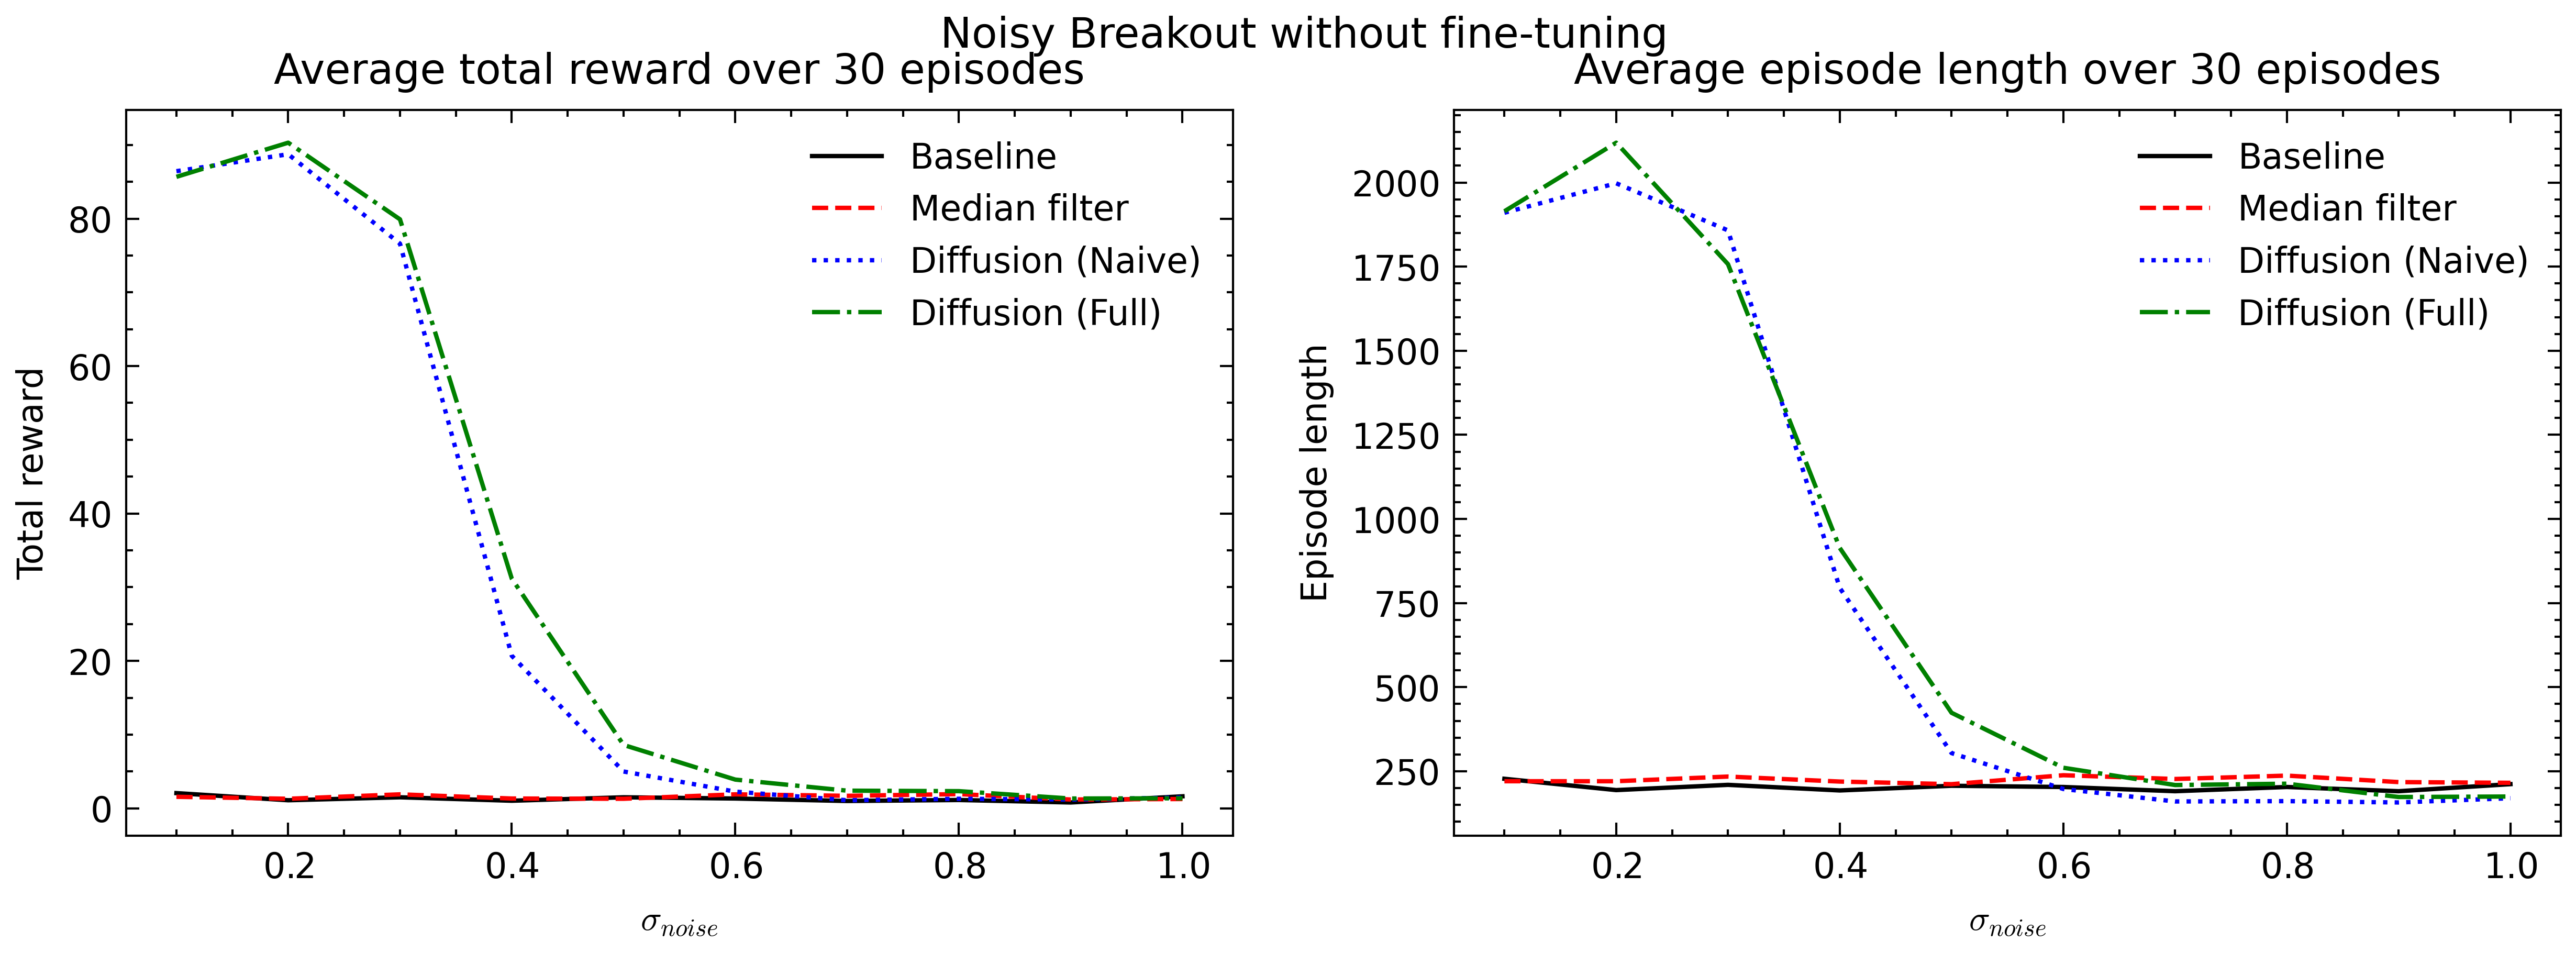

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(10, 3))

axis[0].plot(sigmas, reward_baseline, label="Baseline")
axis[0].plot(sigmas, reward_median, label="Median filter")
axis[0].plot(sigmas, reward_diffusion_naive, label="Diffusion (Naive)")
axis[0].plot(sigmas, reward_diffusion_full, label="Diffusion (Full)")

axis[0].set_ylabel("Total reward")
axis[0].set_xlabel("$\\sigma_{noise}$")

# axis[0].set_title("Average total reward over 30 episodes")

axis[0].legend()

axis[1].plot(sigmas, lengths_baseline, label="Baseline")
axis[1].plot(sigmas, lengths_median, label="Median filter")
axis[1].plot(sigmas, lengths_diffusion_naive, label="Diffusion (Naive)")
axis[1].plot(sigmas, lengths_diffusion_full, label="Diffusion (Full)")

axis[1].set_ylabel("Episode length")
axis[1].set_xlabel("$\\sigma_{noise}$")

# axis[1].set_title("Average episode length over 30 episodes")

axis[1].legend()

fig.suptitle("Noisy Breakout without fine-tuning")

plt.show()